In [2]:
import paramClassSheared
import numpy as np
import matplotlib.pyplot as plt
import os
import psutil

pList = paramClassSheared.generate()

In [3]:
# Define useful functions 
def load_binary(varName,p):
    
    filePath = p.dirPath + varName + "_" + p.tStamp
    X = np.memmap(filePath, dtype="single", mode="r",shape=(p.Nx,p.Ny,p.Nz), order="F")
    return X[:-2,:,:] #Chop off two rows of zeros

def compute_chi(p):
    
    dx = p.Lx/p.Nx
    dy = p.Ly/p.Ny
    dz = p.Lz/p.Nz
        
    #Load in density and compute gradients
    r = load_binary("r", p)
    rx = np.gradient(r,dx,axis=0)
    ry = np.gradient(r,dx,axis=1)
    rz = np.gradient(r,dz,axis=2)

    chi = -p.kinV/(p.dGrad*p.Pr) * (rx**2+ry**2+rz**2)
    
    return chi
    
from mpl_toolkits.axes_grid1 import make_axes_locatable

def imshow_with_cbar(ax, Z, cmap, vmin, vmax, cbar_label):
    im = ax.imshow(Z.T, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3.5%", pad=0.08)
    cb = ax.figure.colorbar(im, cax=cax)
    cb.set_label(cbar_label)
    return im, cb
    
def set_index_axis(
    ax,
    axis="x",
    N=1,
    label=None,
    nticks=5
):
    """
    Set axis ticks in index space (0 ... N).

    Parameters
    ----------
    ax : matplotlib axis
    axis : 'x' or 'y'
    N : int, number of grid points (Nx, Ny, Nz)
    label : axis label (optional)
    nticks : number of ticks (default 5)
    """
    ticks = np.linspace(0, N, nticks, dtype=int)

    if axis == "x":
        ax.set_xticks(ticks)
        ax.set_xticklabels([f"{t}" for t in ticks])
        if label:
            ax.set_xlabel(label)
    elif axis == "y":
        ax.set_yticks(ticks)
        ax.set_yticklabels([f"{t}" for t in ticks])
        if label:
            ax.set_ylabel(label)
            

def memory_report(globals_dict=None, min_gb=0.05):
    """
    Print a report of NumPy array memory usage and container / node memory.
    
    Parameters
    ----------
    globals_dict : dict
        Namespace to inspect (use globals() from caller)
    min_gb : float
        Minimum array size (GB) to display
    """
    if globals_dict is None:
        globals_dict = globals()

    # ---- NumPy arrays ----
    rows = []
    for name, obj in globals_dict.items():
        if isinstance(obj, np.ndarray):
            size_gb = obj.nbytes / 1024**3
            if size_gb >= min_gb:
                rows.append((name, size_gb, obj.shape, obj.dtype))
    rows.sort(key=lambda x: x[1], reverse=True)

    if rows:
        for name, size_gb, shape, dtype in rows:
            print(f"{name:25s} {size_gb:6.2f} GB  shape={shape}  dtype={dtype}")
    else:
        print("(No NumPy arrays above threshold)")

    # ---- current process usage ----
    process = psutil.Process(os.getpid())
    used_gb = process.memory_info().rss / 1024**3

    # ---- node memory ----
    vm = psutil.virtual_memory()
    node_total_gb = vm.total / 1024**3

    # ---- container (cgroup) limit ----
    def _cgroup_limit_gb():
        paths = [
            "/sys/fs/cgroup/memory.max",              # cgroup v2
            "/sys/fs/cgroup/memory/memory.limit_in_bytes"  # cgroup v1
        ]
        for p in paths:
            if os.path.exists(p):
                with open(p) as f:
                    val = f.read().strip()
                if val.isdigit():
                    return int(val) / 1024**3
        return None

    limit_gb = _cgroup_limit_gb()
    avail_to_me_gb = max(limit_gb - used_gb, 0) if limit_gb else None

    # ---- summary ----
    print()
    print(f"{'Notebook memory used':25s}: {used_gb:6.2f} GB")
    print(f"{'Container memory limit':25s}: {limit_gb:6.2f} GB")
    print(f"{'Remaining available to me':25s}: {avail_to_me_gb:6.2f} GB")
    print(f"{'Total node memory':25s}: {node_total_gb:6.2f} GB")

In [4]:
# Load in simulation parameters from the parameter list
p = pList["R1P1"]

x = np.linspace(0.0, p.Lx, p.Nx, endpoint=False)
y = np.linspace(0.0, p.Ly, p.Ny, endpoint=False)
z = np.linspace(0.0, p.Lz, p.Nz, endpoint=False)

In [5]:
# Load in actual simulation data from the parameter list
u = load_binary("u",p)
v = load_binary("v",p)
w = load_binary("w",p)
r = load_binary("r",p)

# Compute mixing
chi = compute_chi(p)

In [6]:
r.max()

0.0009088013

In [7]:
memory_report(globals(), min_gb=0.2)

u                           1.69 GB  shape=(1534, 768, 384)  dtype=float32
v                           1.69 GB  shape=(1534, 768, 384)  dtype=float32
w                           1.69 GB  shape=(1534, 768, 384)  dtype=float32
r                           1.69 GB  shape=(1534, 768, 384)  dtype=float32
chi                         1.69 GB  shape=(1534, 768, 384)  dtype=float32

Notebook memory used     :   3.49 GB
Container memory limit   :  12.00 GB
Remaining available to me:   8.51 GB
Total node memory        : 250.98 GB


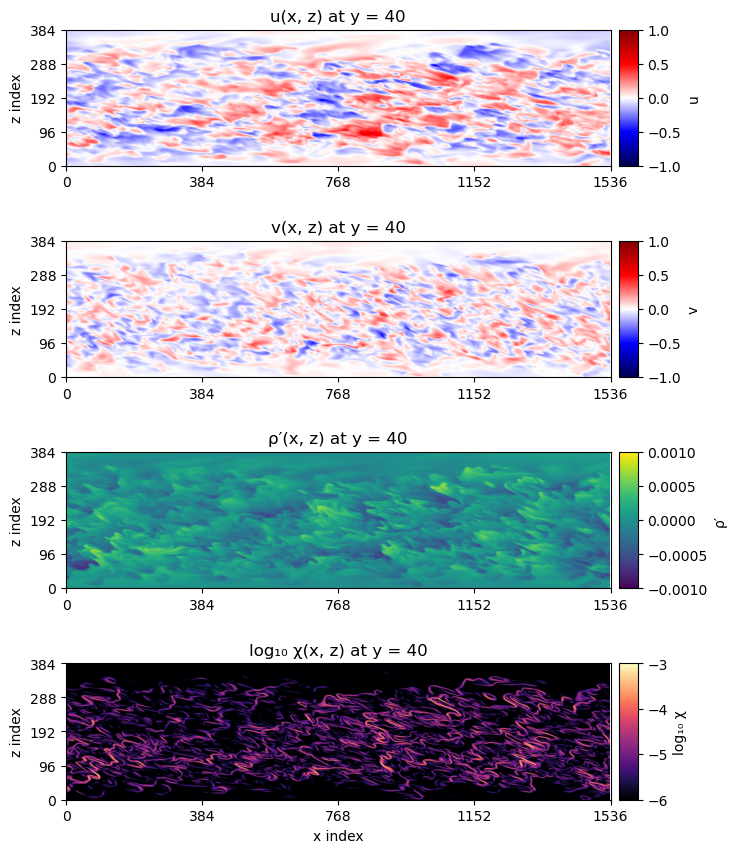

In [12]:
# Plot several slices

# Pick a y index to plot vertical slices
yIdx = 40

fig, axs = plt.subplots(4, 1, figsize=(14, 10))
fig.subplots_adjust(hspace=0.55)

imshow_with_cbar(axs[0], u[:, yIdx, :], "seismic", -1, 1, "u")
axs[0].set_title(f"u(x, z) at y = {yIdx}")
set_index_axis(axs[0], "x", p.Nx, " ")
set_index_axis(axs[0], "y", p.Nz, "z index")

imshow_with_cbar(axs[1], v[:, yIdx, :], "seismic", -1, 1, "v")
axs[1].set_title(f"v(x, z) at y = {yIdx}")
set_index_axis(axs[1], "x", p.Nx, " ")
set_index_axis(axs[1], "y", p.Nz, "z index")

imshow_with_cbar(axs[2], r[:, yIdx, :], "viridis", -1e-3, 1e-3, "ρ′")
axs[2].set_title(f"ρ′(x, z) at y = {yIdx}")
set_index_axis(axs[2], "x", p.Nx, " ")
set_index_axis(axs[2], "y", p.Nz, "z index")

imshow_with_cbar(axs[3], np.log10(chi[:, yIdx, :]), "magma", -6, -3, "log₁₀ χ")
axs[3].set_title(f"log₁₀ χ(x, z) at y = {yIdx}")
set_index_axis(axs[3], "x", p.Nx, "x index")
set_index_axis(axs[3], "y", p.Nz, "z index")